[并查集 Union-Find](data_structure/union_find.md)  

用于处理不相交集合 (disjoint sets) 合并及查找的问题，典型应用有连通分量检测，环路检测等。  
原理和复杂度分析是？  https://blog.csdn.net/the_zed/article/details/105126583    
每个人都只认自己的上级  
- find() 
  -    
join() 也叫  union()  


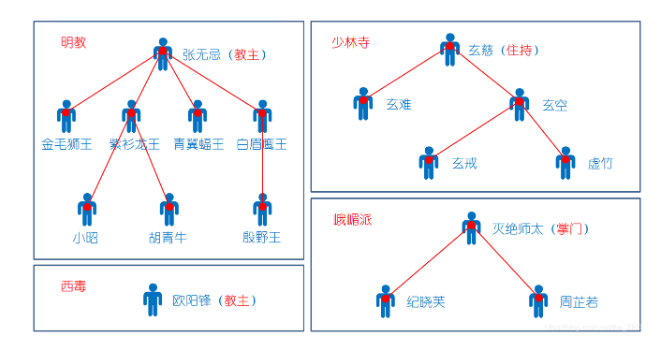

In [ ]:
edges = [[1,2], [1,3], [2,3]]
parent = list(range(4))
print(parent)
rank = [1] *  (len(edges) +1 )
print(rank)
def findRedundantConnection(edges):
    # 初始化自己是自己的代表元，且自己门派只有一人
    parent = list(range(len(edges) +1 ))
    
    rank = [1] *  (len(edges) +1 )
    def find(x):
        # 查找 x 的代表元, 代表元是谁？
        if parent[parent[x]] != parent[x]:
            parent[x] = find(parent[x])  # 路径压缩，防止树太高
        return parent[x]
    def union(x, y):
        # 函数的作用就是用来实现这个的（将两个节点合并到一棵树中）

        px , py = find(x), find(y)

        if px == py:
            return False
        # union by rank, 稍微复杂一点的联合
        if rank[px] > rank[py]:
            parent[py] = px
        elif rank[px] < rank[py]:
            parent[px] = py
        else:
            parent[px] = py
            rank[py] += 1
        print(parent) 
        return True
    
    
    for edge in edges:
        if not union(edge[0],edge[1]):
            # 两个节点本来就在一颗树中，所以是冗余的
            return edge
    return edges

# 用并查集边扫边合并，第一条让两个已连通节点再连一次的边就是冗余边。
findRedundantConnection(edges)

[0, 1, 2, 3]
[1, 1, 1, 1]
[0, 2, 2, 3]
[0, 2, 2, 2]


[2, 3]

<!-- Python 默认的 sorted() 对字符串排序是 按字典序（ASCII/Unicode 顺序）。 -->

Python 默认的 sorted() 对字符串排序是 按字典序（ASCII/Unicode 顺序）。

In [42]:
import collections

def accountMerge(accounts):
    # 
    parent, rank = [], []
    
    def find(x):
        if parent[parent[x]] != parent[x]:
            parent[x] = find(parent[x])
        return parent[x]
    
    def union(x,y):
        px, py = find(x), find(y)
        if px == py:
            return
        if rank[px] > rank[py]:
            parent[py] = px
        elif rank[px] < rank[py]:
            parent[px] = py
        else:
            parent[px] = py
            rank[py] += 1
        return
    
    email2name = {}
    email2idx = {}
    index = 0
    for account in accounts:
        name = account[0]
        emails = account[1:]
        for email in emails:
            email2name[email] = name
            if email not in email2idx:
                parent.append(index)
                rank.append(1)
                # 
                email2idx[email] = index
                index += 1
            # 逐个合并，第一个是代表元
            union(email2idx[account[1]], email2idx[email])
    # 每个账户下的邮箱都合并了，下面是合并账户了
    # print(email2name)
    result = collections.defaultdict(list)
    for email in email2name:
        result[find(email2idx[email])].append(email)
    return [[email2name[res[0]]]+ sorted(res) for res in result.values()]

accounts = [["John", "johnsmith@mail.com", "john00@mail.com"], ["John", "johnnybravo@mail.com"], ["John", "johnsmith@mail.com", "john_newyork@mail.com"], ["Mary", "mary@mail.com"]]  
accountMerge(accounts)

[['John', 'john00@mail.com', 'john_newyork@mail.com', 'johnsmith@mail.com'],
 ['John', 'johnnybravo@mail.com'],
 ['Mary', 'mary@mail.com']]

连续序列：是指两个元素的差值为1

In [46]:
def longestConsecutive(nums):
    parent, length  = {}, {}
    
    def find(x):
        if parent[parent[x]] != parent[x]:
            parent[x] = find(parent[x])
        return parent[x]
    
    def union(x,y):
        px, py = find(x), find(y)
        if px == py:
            return
        # union by size
        if length[px] > length[py]:
            parent[py] = px
            length[px] += length[py]
        else:
            parent[px] = py
            length[py] += length[px]
        return
    # 每个都不联通
    for num in nums:
        parent[num] = num
        length[num] = 1
    print(parent)
    print(length)
    max_length = 0
    for num in nums:
        # 合并的条件是？
        if num+1 in parent:
            union(num+1,num)
        if num-1 in parent:
            union(num-1,num)
        max_length = max(max_length, length[parent[num]])
    return max_length
        
nums = [100,4,200,1,3,2]
longestConsecutive(nums)

{100: 100, 4: 4, 200: 200, 1: 1, 3: 3, 2: 2}
{100: 1, 4: 1, 200: 1, 1: 1, 3: 1, 2: 1}


4